In [1]:
# lib's

import os
import numpy as np
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras.applications import VGG16

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Reshape, Input
from tensorflow.keras.layers import LeakyReLU

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, cohen_kappa_score, log_loss
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

import joblib

from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

import glob
from PIL import Image
import json
import csv

# !pip install sentence-transformers
from sentence_transformers import SentenceTransformer, util
import torch

C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# variables - dataset path
train_data_path = os.path.join('..', 'Dataset', 'artefact2', 'train') 
val_data_path = os.path.join('..', 'Dataset', 'artefact2', 'val')
test_data_path = os.path.join('..', 'Dataset', 'artefact2', 'test')


In [3]:
# Load and Preprocess Images
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = datagen.flow_from_directory(train_data_path, target_size=(224, 224), batch_size=32, class_mode='categorical')
val_data = datagen.flow_from_directory(val_data_path, target_size=(224, 224), batch_size=32, class_mode='categorical')
test_data = datagen.flow_from_directory(test_data_path, target_size=(224, 224), batch_size=32, class_mode='categorical')


Found 720 images belonging to 18 classes.
Found 324 images belonging to 18 classes.
Found 468 images belonging to 18 classes.


In [4]:
# Build a DCGAN
# Generator (Feature Generator)
def build_generator(noise_dim, output_dim):
    input_noise = Input(shape=(noise_dim,))
    x = Dense(128, activation='relu')(input_noise)
    x = Dense(output_dim, activation='linear')(x)  # match feature vector size
    model = Model(input_noise, x)
    return model

# Discriminator
def build_discriminator(input_dim):
    input_feat = Input(shape=(input_dim,))
    x = Dense(128)(input_feat)
    x = LeakyReLU(alpha=0.2)(x)
    x = Dense(1, activation='sigmoid')(x)
    model = Model(input_feat, x)
    return model

# Feature Extractor 
def build_feature_extractor():
    base_model = VGG16(weights='imagenet', include_top=False, pooling='avg', input_shape=(224, 224, 3))
    return base_model

# # Create the feature extractor
feature_extractor = build_feature_extractor()
feature_extractor.summary()



Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0   

In [5]:
# # Train the GAN

# # Assumptions
# noise_dim = 100
# feature_dim = 512  # e.g., from CNN like VGG16 with global average pooling
# batch_size = 64
# epochs = 11 # 10000

# generator = build_generator(noise_dim, feature_dim)
# discriminator = build_discriminator(feature_dim)

# # Compile discriminator
# discriminator.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# # Freeze discriminator during generator training
# discriminator.trainable = False

# # GAN = generator + discriminator
# noise_input = tf.keras.Input(shape=(noise_dim,))
# generated_feature = generator(noise_input)
# validity = discriminator(generated_feature)

# gan = tf.keras.Model(noise_input, validity)
# gan.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# # Prepare real feature vectors
# real_features, real_labels = [], []
# for X, y in train_data:
#     feat = feature_extractor.predict(X)
#     real_features.append(feat)
#     real_labels.append(y)
#     if len(real_features)*batch_size > 10000:
#         break

# real_features = np.vstack(real_features)
# real_labels = np.argmax(np.vstack(real_labels), axis=1)


In [6]:
# # Training loop
# for epoch in range(epochs):
#     # ---------------------
#     # Train Discriminator
#     # ---------------------
#     idx = np.random.randint(0, real_features.shape[0], batch_size)
#     real_feat_batch = real_features[idx]

#     noise = np.random.normal(0, 1, (batch_size, noise_dim))
#     fake_feat_batch = generator.predict(noise)

#     # Labels
#     real_y = np.ones((batch_size, 1))
#     fake_y = np.zeros((batch_size, 1))

#     # Train discriminator
#     d_loss_real = discriminator.train_on_batch(real_feat_batch, real_y)
#     d_loss_fake = discriminator.train_on_batch(fake_feat_batch, fake_y)
#     d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

#     # ---------------------
#     # Train Generator
#     # ---------------------
#     noise = np.random.normal(0, 1, (batch_size, noise_dim))
#     valid_y = np.ones((batch_size, 1))  # Trick GAN: fake should be labeled real

#     g_loss = gan.train_on_batch(noise, valid_y)

#     if epoch % 10 == 0:
#         print(f"{epoch} [D loss: {d_loss[0]} | D acc.: {100*d_loss[1]:.2f}] [G loss: {g_loss[0]:.4f}]")
        


In [7]:
# # Feature Extraction + Label Collection

# X_train_features = []
# y_train_labels = []

# # Loop over train_data batches
# for images, labels in train_data:
#     features = feature_extractor.predict(images)
#     X_train_features.append(features)
#     y_train_labels.append(np.argmax(labels, axis=1))  # categorical class_mode
    
#     # break early if too large
#     if len(X_train_features) * train_data.batch_size > 10000:
#         break

# # Stack all batches into arrays
# X_train_features = np.vstack(X_train_features)
# y_train_labels = np.concatenate(y_train_labels)


In [8]:
# data = pd.DataFrame(X_train_features)
# data['lable'] = y_train_labels
# data.head()

In [9]:
# data.to_csv('GAN_based_feature.csv', index=False)

# Random Forest Classifier

In [10]:
data = pd.read_csv('GAN_based_feature.csv')
data.head()

,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,lable
0,0.174045,1.865967,11.591558,0.008033,45.040230,0.311282,5.612297,1.865406,15.676640,2.282927,...,4.610763,0.961468,6.207984,1.200334,0.044280,0.000000,4.170618,0.516284,10.323720,10
1,0.000000,0.095043,0.694484,0.000000,3.757998,0.360009,0.000000,0.860971,1.150867,0.072196,...,0.347403,2.240694,0.000000,1.139284,0.036443,0.000000,0.000000,0.135159,0.085367,1
2,0.070133,0.000000,1.511615,0.638302,2.095962,0.000000,0.000000,0.550697,4.736321,3.490557,...,0.000000,1.690517,1.724687,1.701750,0.153255,0.274049,5.894151,2.031699,0.000000,4
3,0.000000,0.000000,0.000000,0.000000,0.972159,0.658794,0.000000,0.000000,1.294671,5.071178,...,0.000000,2.837131,0.000000,0.000000,0.000000,0.000000,0.260011,0.081601,7.348356,6
4,5.361132,0.393039,4.176789,0.000000,14.282092,2.911334,0.000000,6.938582,5.518541,0.277272,...,0.043850,3.090395,7.996645,1.628472,0.122883,0.000000,0.764273,3.141874,0.000000,0


In [11]:
# Classification Model on Generated Features
X_train_features = data.drop(columns='lable')
y_train_labels = data['lable']


# Train RF classifier on generated + real features (with labels)
rf_model = RandomForestClassifier()
rf_model.fit(X_train_features, y_train_labels)


RandomForestClassifier()


MODEL EVALUATION
Accuracy: 100.00 %
Log Loss: 0.00 %
ROC-AUC: 100.00 %
Cohen's Kappa Score: 100.00 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       547
           1       1.00      1.00      1.00       550
           2       1.00      1.00      1.00       551
           3       1.00      1.00      1.00       546
           4       1.00      1.00      1.00       537
           5       1.00      1.00      1.00       546
           6       1.00      1.00      1.00       537
           7       1.00      1.00      1.00       540
           8       1.00      1.00      1.00       540
           9       1.00      1.00      1.00       541
          10       1.00      1.00      1.00       542
          11       1.00      1.00      1.00       538
          12       1.00      1.00      1.00       550
          13       1.00      1.00      1.00       545
          14       1.00      1.00      1.00       550
         

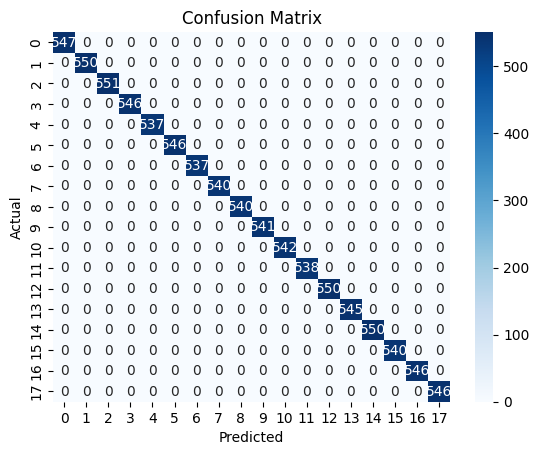

In [12]:
def evaluate_model(test_labels, pred_labels, pred_labels_proba):
    '''
    This function is use to model evaluation.
    
    Input:
    test_labels : Actual test lebels.
    pred_labels : Predicted labels.
    
    Output: None
    '''
    # Evaluate the model
    print("\n" + "="*50)
    print("MODEL EVALUATION")
    print("="*50)

    # Accuracy
    acc = accuracy_score(test_labels, pred_labels)

    # Log loss
    loss = 1 - acc
    
    # AUC-ROC
    roc_auc = roc_auc_score(test_labels, pred_labels_proba, multi_class='ovr') # .to_numpy().reshape(-1, 1)

    # Cohen's Kappa Score
    kappa = cohen_kappa_score(test_labels, pred_labels)

    # Print results
    print(f"Accuracy: {acc*100:.2f} %")
    print(f"Log Loss: {loss*100:.2f} %")
    print(f"ROC-AUC: {roc_auc*100:.2f} %")
    print(f"Cohen's Kappa Score: {kappa*100:.2f} %\n")
    print("classification_report:")
    print(classification_report(test_labels, pred_labels))

    # Confusion Matrix
    cm = confusion_matrix(test_labels, pred_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
# # ROC-AUC score (handles both binary and multiclass)
# if len(np.unique(y)) == 2:
#     # Binary classification
#     train_auc = roc_auc_score(y_train, y_train_proba[:, 1])
#     test_auc = roc_auc_score(y_test, y_test_proba[:, 1])
#     print(f"Training ROC-AUC: {train_auc:.4f}")
#     print(f"Testing ROC-AUC: {test_auc:.4f}")
# else:
#     # Multiclass classification
#     train_auc = roc_auc_score(y_train, y_train_proba, multi_class='ovr')
#     test_auc = roc_auc_score(y_test, y_test_proba, multi_class='ovr')
#     print(f"Training ROC-AUC (OVR): {train_auc:.4f}")
#     print(f"Testing ROC-AUC (OVR): {test_auc:.4f}")
    
# # Feature importance (optional)
# feature_importance = pd.DataFrame({
#     'feature': feature_names,
#     'importance': rf_model.feature_importances_
# }).sort_values('importance', ascending=False)

# print("\nTop 10 Important Features:")
# print(feature_importance.head(10))

# # Check for overfitting
# print(f"\nOverfitting Check:")
# print(f"Train-Test Accuracy Difference: {abs(train_accuracy - test_accuracy):.4f}")
# if abs(train_accuracy - test_accuracy) > 0.1:
#     print("Warning: Model might be overfitting!")
# else:
#     print("No significant overfitting detected.")


# Evaluate Model
y_pred = rf_model.predict(X_train_features)
y_pred_proba = rf_model.predict_proba(X_train_features)

evaluate_model(y_train_labels, y_pred, y_pred_proba)

# Test Features

In [ ]:
# # Extract Test Features

# X_test_features = []
# y_test_labels = []

# # Loop over test_data batches
# for images, labels in test_data:
#     features = feature_extractor.predict(images)
#     X_test_features.append(features)
#     y_test_labels.append(np.argmax(labels, axis=1))  # if using categorical labels

#     # Optional: limit size
#     if len(X_test_features) * test_data.batch_size > 1000:
#         break

# # Stack arrays
# X_test_features = np.vstack(X_test_features)
# y_test_labels = np.concatenate(y_test_labels)


In [ ]:
# data = pd.DataFrame(X_test_features)
# data['lable'] = y_test_labels
# display(data.head())

# data.to_csv('GAN_based_feature_Test Features.csv', index=False)

In [13]:
data = pd.read_csv('GAN_based_feature_Test Features.csv')
data.head()

,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,lable
0,0.174045,1.865967,11.591558,0.008033,45.040230,0.311282,5.612297,1.865406,15.676640,2.282927,...,4.610763,0.961468,6.207984,1.200334,0.044280,0.000000,4.170618,0.516284,10.323720,10
1,0.000000,0.095043,0.694484,0.000000,3.757998,0.360009,0.000000,0.860971,1.150867,0.072196,...,0.347403,2.240694,0.000000,1.139284,0.036443,0.000000,0.000000,0.135159,0.085367,1
2,0.070133,0.000000,1.511615,0.638302,2.095962,0.000000,0.000000,0.550697,4.736321,3.490557,...,0.000000,1.690517,1.724687,1.701750,0.153255,0.274049,5.894151,2.031699,0.000000,4
3,0.000000,0.000000,0.000000,0.000000,0.972159,0.658794,0.000000,0.000000,1.294671,5.071178,...,0.000000,2.837131,0.000000,0.000000,0.000000,0.000000,0.260011,0.081601,7.348356,6
4,5.361132,0.393039,4.176789,0.000000,14.282092,2.911334,0.000000,6.938582,5.518541,0.277272,...,0.043850,3.090395,7.996645,1.628472,0.122883,0.000000,0.764273,3.141874,0.000000,0



MODEL EVALUATION
Accuracy: 100.00 %
Log Loss: 0.00 %
ROC-AUC: 100.00 %
Cohen's Kappa Score: 100.00 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       547
           1       1.00      1.00      1.00       550
           2       1.00      1.00      1.00       551
           3       1.00      1.00      1.00       546
           4       1.00      1.00      1.00       537
           5       1.00      1.00      1.00       546
           6       1.00      1.00      1.00       537
           7       1.00      1.00      1.00       540
           8       1.00      1.00      1.00       540
           9       1.00      1.00      1.00       541
          10       1.00      1.00      1.00       542
          11       1.00      1.00      1.00       538
          12       1.00      1.00      1.00       550
          13       1.00      1.00      1.00       545
          14       1.00      1.00      1.00       550
         

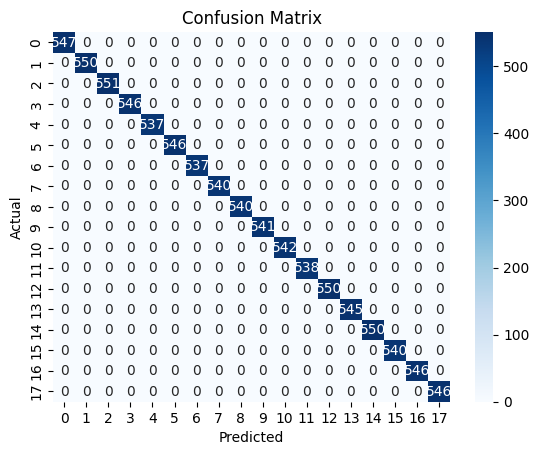

In [14]:
# Classification Model on Generated Features
X_test_features = data.drop(columns='lable')
y_test_labels = data['lable']


# Evaluate Model
y_pred = rf_model.predict(X_test_features)
y_pred_proba = rf_model.predict_proba(X_test_features)

evaluate_model(y_test_labels, y_pred, y_pred_proba)

# Val Features

In [ ]:
# # Feature Extraction + Label Collection

# X_val_features = []
# y_val_labels = []

# # Loop over train_data batches
# for images, labels in val_data:
#     features = feature_extractor.predict(images)
#     X_val_features.append(features)
#     y_val_labels.append(np.argmax(labels, axis=1))  # assuming categorical class_mode
    
#     # Optional: break early if too large
#     if len(X_val_features) * val_data.batch_size > 10000:
#         break

# # Stack all batches into arrays
# X_val_features = np.vstack(X_val_features)
# y_val_labels = np.concatenate(y_val_labels)


# data = pd.DataFrame(X_val_features)
# data['lable'] = y_val_labels
# display(data.head())

# data.to_csv('GAN_based_feature_Val Features.csv', index=False)

In [15]:
data = pd.read_csv('GAN_based_feature_Val Features.csv')
data.head()

,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,lable
0,0.000000,0.000000,1.575691,0.000000,2.442428,1.078944,0.000000,0.389381,0.023333,0.409375,...,0.000000,3.704303,0.348193,1.177873,0.000000,0.000000,0.000000,0.000000,0.497695,15
1,0.000000,0.000000,0.000000,0.028345,0.000000,0.557634,0.655866,0.000000,0.032162,0.340983,...,0.363608,0.755673,0.000000,1.771733,0.000000,0.000000,2.806723,0.000000,0.002174,1
2,0.365661,1.057705,8.298944,0.000000,6.748331,3.954115,0.154565,4.744651,1.190314,1.918098,...,0.061580,0.063607,3.626506,5.364040,0.180991,0.116253,0.001304,1.458270,0.086630,3
3,2.936886,3.301601,4.211963,0.504223,2.113750,4.960781,0.019724,4.922066,3.381042,1.318046,...,0.000000,1.408347,14.497631,1.671928,0.511498,0.000000,0.309708,1.305904,0.262329,16
4,13.750863,0.102478,12.586039,0.358917,4.453012,0.000000,0.735848,0.349736,2.444673,1.692135,...,1.132116,0.428990,5.281471,2.228343,1.014484,1.010291,1.400669,0.240402,0.000000,7



MODEL EVALUATION
Accuracy: 96.27 %
Log Loss: 3.73 %
ROC-AUC: 99.97 %
Cohen's Kappa Score: 96.05 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       513
           1       0.94      0.83      0.88       515
           2       0.95      1.00      0.97       513
           3       1.00      0.89      0.94       509
           4       0.95      1.00      0.97       515
           5       0.95      1.00      0.97       509
           6       0.89      0.95      0.92       512
           7       0.95      1.00      0.97       512
           8       1.00      0.83      0.91       512
           9       1.00      0.89      0.94       516
          10       1.00      1.00      1.00       512
          11       1.00      1.00      1.00       514
          12       0.95      1.00      0.97       513
          13       0.94      0.95      0.94       511
          14       0.95      1.00      0.97       515
          15

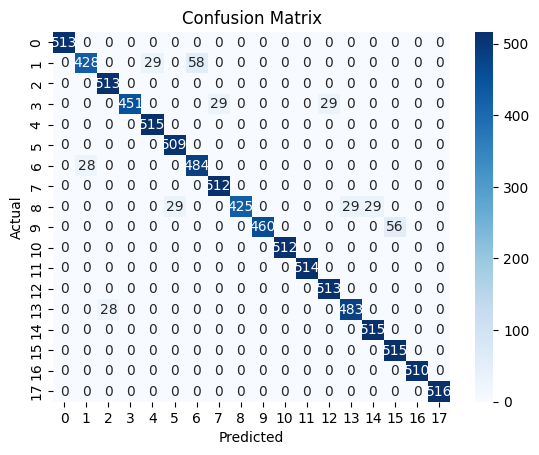

In [16]:
# Classification Model on Generated Features
X_val_features = data.drop(columns='lable')
y_val_labels = data['lable']


# Evaluate Model
y_pred = rf_model.predict(X_val_features)
y_pred_proba = rf_model.predict_proba(X_val_features)

evaluate_model(y_val_labels, y_pred, y_pred_proba)

In [ ]:
# # Save the Model and Features

# # Save RF model
# joblib.dump(rf_model, 'zsl_classifier_rf.pkl')

# # Save CNN Feature Extractor
# feature_extractor.save('cnn_feature_extractor.h5')


In [18]:
# Predict on a New Image

# Load models
rf_model = joblib.load('zsl_classifier_rf.pkl')
feature_extractor = load_model('cnn_feature_extractor.h5')

# Reverse the class_indices from train_data
# print(train_data.class_indices)
idx_to_class = {v: k for k, v in train_data.class_indices.items()}

# CSV output file
csv_file_path = "prediction_results_generator_rf.csv"

if os.path.exists(csv_file_path):
    os.remove(csv_file_path)
    print(f"{csv_file_path} deleted successfully")
else:
    print(f"{csv_file_path} does not exist")

def prediction_generator(image_paths, csv_file_path):
    for img_path in image_paths:
        try:
            act_class = img_path.split('\\')[-2]
            
            # Preprocess image
            img = image.load_img(img_path, target_size=(224, 224))
            img_array = image.img_to_array(img)
            img_array = preprocess_input(img_array)
            img_array = np.expand_dims(img_array, axis=0)

            # Extract features & predict
            features = feature_extractor.predict(img_array)
            probs = rf_model.predict_proba(features) # [0]
            predicted_class = rf_model.classes_[np.argmax(probs)]
            class_name = idx_to_class[predicted_class]
            confidence = np.max(probs)
            
            # Write header once
            if not os.path.exists(csv_file_path):
                with open(csv_file_path, mode='w', newline='') as f:
                    writer = csv.writer(f)
                    writer.writerow(["Image Path", "Actual Class", "Predicted Class", "Class Name", "Probability", "Predicted Class Probability"])

            # Log to CSV
            with open(csv_file_path, mode='a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([img_path, act_class, predicted_class, class_name, f"{confidence:.4f}", probs])

        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue
            
# Predict for all images in a folder
img_dir = os.path.join('..', 'Dataset', 'artefact2', 'test', '*', '*') # '../Dataset/artefact2/test/*/*'
image_paths = glob.glob(img_dir)
prediction_generator(image_paths, csv_file_path)


prediction_results_generator_rf.csv deleted successfully
1/1 [==============================] - 1s 864ms/step


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


1/1 [==============================] - 1s 558ms/step


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


1/1 [==============================] - 1s 505ms/step


...

C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


1/1 [==============================] - 0s 260ms/step


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


1/1 [==============================] - 0s 293ms/step


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [19]:
# CSV output file
csv_file_path = "prediction_results_generator_rf.csv"
df = pd.read_csv(csv_file_path)
df.head()

,Image Path,Actual Class,Predicted Class,Class Name,Probability,Predicted Class Probability
0,..\Dataset\artefact2\test\bear\bear_10001 (23)...,bear,0,bear,1.0,[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0....
1,..\Dataset\artefact2\test\bear\bear_10001 (24)...,bear,0,bear,1.0,[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0....
2,..\Dataset\artefact2\test\bear\bear_10001 (25)...,bear,0,bear,1.0,[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0....
3,..\Dataset\artefact2\test\bear\bear_10001 (26)...,bear,0,bear,1.0,[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0....
4,..\Dataset\artefact2\test\bear\bear_10001 (27)...,bear,0,bear,1.0,[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0....


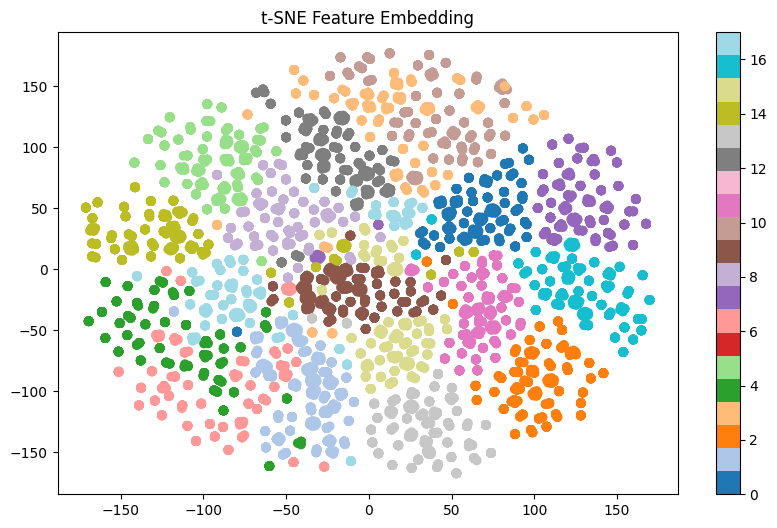

In [20]:
# Visualize Feature Space with t-SNE
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2)
X_embedded = tsne.fit_transform(X_test_features)

plt.figure(figsize=(10, 6))
plt.scatter(X_embedded[:,0], X_embedded[:,1], c=y_test_labels, cmap='tab20')
plt.title("t-SNE Feature Embedding")
plt.colorbar()
plt.show()


In [ ]:
# model = SentenceTransformer('all-MiniLM-L6-v2') # <--- Change the models here ---<<<

# words = list(idx_to_class.values()) # ['tiger', 'lion', 'cat', 'dog', 'truck']
# embeddings = model.encode(words, convert_to_tensor=True)

# # Find top 3 similar to 'tiger'
# query = model.encode('cat', convert_to_tensor=True)
# cosine_scores = util.cos_sim(query, embeddings)

# # Show top-3 results
# top_results = torch.topk(cosine_scores[0], k=5)
# for idx in top_results.indices:
#     print(words[idx], float(cosine_scores[0][idx]))

In [23]:
model = SentenceTransformer('all-MiniLM-L6-v2') # <--- Change the models here ---<<<

words = list(idx_to_class.values()) # ['tiger', 'lion', 'cat', 'dog', 'truck']
embeddings = model.encode(words, convert_to_tensor=True)
similar_wds, similar_wds_cos_scores = [], []

for _, row in df.iterrows():
#     print(row['Class Name'])
    # Find top n similar 
    query = model.encode(row['Class Name'], convert_to_tensor=True)
    cosine_scores = util.cos_sim(query, embeddings)

    # Show top-3 results
    top_results = torch.topk(cosine_scores[0], k=5)
    wds, cos_scores = [], []
    for idx in top_results.indices:
#         print(words[idx], float(cosine_scores[0][idx]))
        wds.append(words[idx]) 
        cos_scores.append(float(cosine_scores[0][idx]))
#     break
    similar_wds.append((wds, cos_scores))
    similar_wds_cos_scores.append(cos_scores)

In [24]:
df['similar_wds'] = similar_wds
df['similar_wds_cos_scores'] = similar_wds_cos_scores
df.head()

,Image Path,Actual Class,Predicted Class,Class Name,Probability,Predicted Class Probability,similar_wds,similar_wds_cos_scores
0,..\Dataset\artefact2\test\bear\bear_10001 (23)...,bear,0,bear,1.0,[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0....,"([bear, walrus, rabbit, squirrel, cow], [1.0, ...","[1.0, 0.5303044319152832, 0.524238109588623, 0..."
1,..\Dataset\artefact2\test\bear\bear_10001 (24)...,bear,0,bear,1.0,[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0....,"([bear, walrus, rabbit, squirrel, cow], [1.0, ...","[1.0, 0.5303044319152832, 0.524238109588623, 0..."
2,..\Dataset\artefact2\test\bear\bear_10001 (25)...,bear,0,bear,1.0,[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0....,"([bear, walrus, rabbit, squirrel, cow], [1.0, ...","[1.0, 0.5303044319152832, 0.524238109588623, 0..."
3,..\Dataset\artefact2\test\bear\bear_10001 (26)...,bear,0,bear,1.0,[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0....,"([bear, walrus, rabbit, squirrel, cow], [1.0, ...","[1.0, 0.5303044319152832, 0.524238109588623, 0..."
4,..\Dataset\artefact2\test\bear\bear_10001 (27)...,bear,0,bear,1.0,[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0....,"([bear, walrus, rabbit, squirrel, cow], [1.0, ...","[1.0, 0.5303044319152832, 0.524238109588623, 0..."


In [25]:
df.to_csv('prediction_results_generator.csv', index=False)

In [26]:
df = pd.read_csv('prediction_results_generator.csv')
zsl_classes = [] 

for _, row in df.iterrows():    
    ActualClass = row['Actual Class']
    SimilarWords = eval(row['similar_wds'])[0]
    
    if ActualClass in SimilarWords:
        zsl_classes.append(words.index(ActualClass))
    else:
        zsl_classes.append(words.index(SimilarWords[0]))

df['ZSL Predicted Class'] = zsl_classes
df.head()

,Image Path,Actual Class,Predicted Class,Class Name,Probability,Predicted Class Probability,similar_wds,similar_wds_cos_scores,ZSL Predicted Class
0,..\Dataset\artefact2\test\bear\bear_10001 (23)...,bear,0,bear,1.0,[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0....,"(['bear', 'walrus', 'rabbit', 'squirrel', 'cow...","[1.0, 0.5303044319152832, 0.524238109588623, 0...",0
1,..\Dataset\artefact2\test\bear\bear_10001 (24)...,bear,0,bear,1.0,[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0....,"(['bear', 'walrus', 'rabbit', 'squirrel', 'cow...","[1.0, 0.5303044319152832, 0.524238109588623, 0...",0
2,..\Dataset\artefact2\test\bear\bear_10001 (25)...,bear,0,bear,1.0,[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0....,"(['bear', 'walrus', 'rabbit', 'squirrel', 'cow...","[1.0, 0.5303044319152832, 0.524238109588623, 0...",0
3,..\Dataset\artefact2\test\bear\bear_10001 (26)...,bear,0,bear,1.0,[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0....,"(['bear', 'walrus', 'rabbit', 'squirrel', 'cow...","[1.0, 0.5303044319152832, 0.524238109588623, 0...",0
4,..\Dataset\artefact2\test\bear\bear_10001 (27)...,bear,0,bear,1.0,[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0....,"(['bear', 'walrus', 'rabbit', 'squirrel', 'cow...","[1.0, 0.5303044319152832, 0.524238109588623, 0...",0


Accuracy: 98.29 %
Log Loss: 1.71 %
ROC-AUC: 99.97 %
Cohen's Kappa Score: 98.19 %

classification_report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        27
           1       0.96      0.96      0.96        26
           2       1.00      1.00      1.00        27
           3       0.89      1.00      0.94        25
           4       0.96      1.00      0.98        25
           5       1.00      0.96      0.98        27
           6       0.96      0.93      0.94        27
           7       1.00      1.00      1.00        26
           8       0.96      1.00      0.98        24
           9       1.00      1.00      1.00        24
          10       1.00      0.93      0.96        27
          11       0.96      1.00      0.98        26
          12       1.00      1.00      1.00        27
          13       1.00      1.00      1.00        23
          14       1.00      1.00      1.00        27
          15       1.00      0

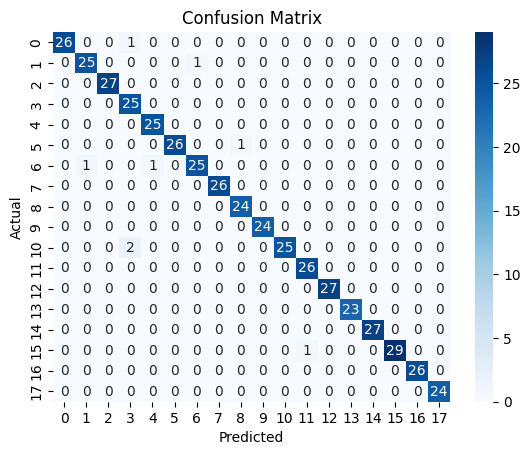

In [64]:
import ast

def convert_string_to_array(array_string):
    """
    Convert string representation of array to actual numpy array
    """
    if isinstance(array_string, str):
        # Clean the string and convert
        try:
            # Remove extra spaces and ensure proper format
            cleaned = array_string.replace(' ', ',').replace('.,', '.').replace('.,', '.')
            python_list = ast.literal_eval(cleaned)
            return np.array(python_list, dtype=np.float32)
        except:
            # Alternative method for different string formats
            try:
                cleaned = array_string.replace('[', '').replace(']', '')
                numbers = [float(x) for x in cleaned.split() if x]
                return np.array(numbers, dtype=np.float32)
            except:
                return np.nan
    elif isinstance(array_string, (list, np.ndarray)):
        return np.array(array_string, dtype=np.float32)
    else:
        return np.nan

# Convert the entire column
df['Predicted Class Probability Array'] = df['Predicted Class Probability'].apply(convert_string_to_array)

# # Check if conversion worked
# print("After conversion - first few arrays:")
# for i, arr in enumerate(df['Predicted Class Probability Array'].head()):
#     print(f"Row {i}: {arr} (shape: {arr.shape if hasattr(arr, 'shape') else 'N/A'})")
    
# Extract the probability scores for the positive class
# Assuming you have a multiclass problem and need to extract probabilities for each class

# Method 1: If you have one-hot encoded probabilities
def extract_probability_scores(probability_arrays):
    """
    Extract probability scores in format suitable for roc_auc_score
    """
    if isinstance(probability_arrays, np.ndarray) and probability_arrays.ndim > 1:
        return probability_arrays  # Already in correct format
    else:
        # Convert list of arrays to 2D array
        return np.vstack(probability_arrays.tolist())

# Convert to proper format
pred_labels_proba = extract_probability_scores(df['Predicted Class Probability Array'])

# print(f"Probability scores shape: {pred_labels_proba.shape}")
# print(f"Test labels shape: {test_labels.shape}")

def evaluate_model_2(test_labels, pred_labels, pred_labels_proba):
    """
    Evaluate model performance with proper handling of probability scores
    """
    # Ensure labels are numpy arrays
    test_labels = np.array(test_labels)
    pred_labels = np.array(pred_labels)
    
    # If pred_labels_proba is a Series of arrays, convert to 2D array
    if hasattr(pred_labels_proba, 'iloc') and isinstance(pred_labels_proba.iloc[0], np.ndarray):
        pred_labels_proba = np.vstack(pred_labels_proba.tolist())
    
    # Accuracy
    acc = accuracy_score(test_labels, pred_labels)
    loss = 1 - acc
    
    # AUC-ROC (handle both binary and multiclass)
    try:
        if len(np.unique(test_labels)) > 2:
            # Multiclass
            roc_auc = roc_auc_score(test_labels, pred_labels_proba, multi_class='ovr')
        else:
            # Binary classification - use probabilities for positive class
            roc_auc = roc_auc_score(test_labels, pred_labels_proba[:, 1] if pred_labels_proba.shape[1] > 1 else pred_labels_proba)
    except Exception as e:
        print(f"ROC-AUC calculation failed: {e}")
        roc_auc = np.nan
    
    # Cohen's Kappa Score
    kappa = cohen_kappa_score(test_labels, pred_labels)
    
    # Classification Report
    class_report = classification_report(test_labels, pred_labels)
    
    # Confusion Matrix
    cm = confusion_matrix(test_labels, pred_labels)
    
    # Print results
    print(f"Accuracy: {acc*100:.2f} %")
    print(f"Log Loss: {loss*100:.2f} %")
    print(f"ROC-AUC: {roc_auc*100:.2f} %")
    print(f"Cohen's Kappa Score: {kappa*100:.2f} %\n")
    print("classification_report:")
    print(classification_report(test_labels, pred_labels))

    # Confusion Matrix
    cm = confusion_matrix(test_labels, pred_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    

test_labels, pred_labels, pred_labels_cos_scores  = df['Predicted Class'], df['ZSL Predicted Class'], df['Predicted Class Probability Array']

evaluate_model_2(test_labels, pred_labels, pred_labels_cos_scores)

## Working with Unseen Dataset

In [70]:
def prediction_generator(image_paths, csv_file_path = "prediction_results.csv"):
    for img_path in image_paths:
        try:
            act_class = img_path.split('\\')[-2]
            
            # Preprocess image
            img = image.load_img(img_path, target_size=(224, 224))
            img_array = image.img_to_array(img)
            img_array = preprocess_input(img_array)
            img_array = np.expand_dims(img_array, axis=0)

            # Extract features & predict
            features = feature_extractor.predict(img_array, verbose=0)
            probs = rf_model.predict_proba(features) # [0]
            predicted_class = rf_model.classes_[np.argmax(probs)]
            class_name = idx_to_class[predicted_class]
            confidence = np.max(probs)
            
            # Write header once
            if not os.path.exists(csv_file_path):
                with open(csv_file_path, mode='w', newline='') as f:
                    writer = csv.writer(f)
                    writer.writerow(["Image Path", "Actual Class", "Predicted Class", "Class Name", "Probability", "Predicted Class Probability"])

            # Log to CSV
            with open(csv_file_path, mode='a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow([img_path, act_class, predicted_class, class_name, f"{confidence:.4f}", probs])

        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue
            
# Predict for all images in a folder
img_dir = os.path.join('..', 'Dataset', 'artefact2', 'unseen', '*', '*') # '../Dataset/artefact2/test/*/*'
image_paths = glob.glob(img_dir)

unseen_csv_file_path = "prediction_results_generator_unseen.csv"
if os.path.exists(unseen_csv_file_path):
    os.remove(unseen_csv_file_path)
    print(f"{unseen_csv_file_path} deleted successfully")
else:
    print(f"{unseen_csv_file_path} does not exist")

    
prediction_generator(image_paths, csv_file_path=unseen_csv_file_path)

df = pd.read_csv(unseen_csv_file_path)
df.head()

prediction_results_generator_unseen.csv deleted successfully


C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have 

C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have 

C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have 

,Image Path,Actual Class,Predicted Class,Class Name,Probability,Predicted Class Probability
0,..\Dataset\artefact2\unseen\chimpanzee\chimpan...,chimpanzee,8,monkey,0.39,[[0.02 0. 0.02 0. 0.04 0.17 0.01 0.03 0.39...
1,..\Dataset\artefact2\unseen\chimpanzee\chimpan...,chimpanzee,5,gorilla,0.31,[[0.03 0. 0.02 0.11 0. 0.31 0.01 0.06 0.1 ...
2,..\Dataset\artefact2\unseen\chimpanzee\chimpan...,chimpanzee,5,gorilla,0.22,[[0.02 0. 0.05 0.04 0.02 0.22 0. 0.05 0.22...
3,..\Dataset\artefact2\unseen\chimpanzee\chimpan...,chimpanzee,8,monkey,0.28,[[0.04 0.01 0.03 0.03 0. 0.24 0.03 0.04 0.28...
4,..\Dataset\artefact2\unseen\chimpanzee\chimpan...,chimpanzee,5,gorilla,0.38,[[0.01 0.01 0.06 0.01 0. 0.38 0.03 0.05 0.24...


In [71]:
model = SentenceTransformer('all-MiniLM-L6-v2')

img_dir = os.path.join('..', 'Dataset', 'artefact2', 'unseen', '*') # '../Dataset/artefact2/test/*'
image_class = sorted([path.split('\\')[-1] for path in glob.glob(img_dir)])
idx_to_unseen_class = {k: v for k, v in enumerate(image_class)}

words = list(idx_to_unseen_class.values()) # ['tiger', 'lion', 'cat', 'dog', 'truck']
embeddings = model.encode(words, convert_to_tensor=True)
similar_wds, similar_wds_cos_scores = [], []

for _, row in df.iterrows():
#     print(row[-2])
    # Find top n similar 
    query = model.encode(row['Class Name'], convert_to_tensor=True)
    cosine_scores = util.cos_sim(query, embeddings)

    # Show top-3 results
    top_results = torch.topk(cosine_scores[0], k=5)
    wds, cos_scores = [], []
    for idx in top_results.indices:
#         print(words[idx], float(cosine_scores[0][idx]))
        wds.append(words[idx]) 
        cos_scores.append(float(cosine_scores[0][idx]))
#     break
    similar_wds.append((wds, cos_scores))
    similar_wds_cos_scores.append(cos_scores)
    
df['similar_wds'] = similar_wds
df['similar_wds_cos_scores'] = similar_wds_cos_scores
df.head()

,Image Path,Actual Class,Predicted Class,Class Name,Probability,Predicted Class Probability,similar_wds,similar_wds_cos_scores
0,..\Dataset\artefact2\unseen\chimpanzee\chimpan...,chimpanzee,8,monkey,0.39,[[0.02 0. 0.02 0. 0.04 0.17 0.01 0.03 0.39...,"([chimpanzee, rat, leopard, raccoon, giant_pan...","[0.6258541345596313, 0.462008535861969, 0.4370..."
1,..\Dataset\artefact2\unseen\chimpanzee\chimpan...,chimpanzee,5,gorilla,0.31,[[0.03 0. 0.02 0.11 0. 0.31 0.01 0.06 0.1 ...,"([chimpanzee, hippopotamus, raccoon, humpback_...","[0.6233536005020142, 0.4889954626560211, 0.437..."
2,..\Dataset\artefact2\unseen\chimpanzee\chimpan...,chimpanzee,5,gorilla,0.22,[[0.02 0. 0.05 0.04 0.02 0.22 0. 0.05 0.22...,"([chimpanzee, hippopotamus, raccoon, humpback_...","[0.6233536005020142, 0.4889954626560211, 0.437..."
3,..\Dataset\artefact2\unseen\chimpanzee\chimpan...,chimpanzee,8,monkey,0.28,[[0.04 0.01 0.03 0.03 0. 0.24 0.03 0.04 0.28...,"([chimpanzee, rat, leopard, raccoon, giant_pan...","[0.6258541345596313, 0.462008535861969, 0.4370..."
4,..\Dataset\artefact2\unseen\chimpanzee\chimpan...,chimpanzee,5,gorilla,0.38,[[0.01 0.01 0.06 0.01 0. 0.38 0.03 0.05 0.24...,"([chimpanzee, hippopotamus, raccoon, humpback_...","[0.6233536005020142, 0.4889954626560211, 0.437..."


In [72]:
df.to_csv('prediction_results_generator_unseen.csv', index=False)

In [73]:
df = pd.read_csv('prediction_results_generator_unseen.csv')
zsl_classes, unseen_class = [], []

for _, row in df.iterrows():    
    ActualClass = row['Actual Class']
    SimilarWords = eval(row['similar_wds'])[0]
    
    if ActualClass in SimilarWords:
        zsl_classes.append(words.index(ActualClass))
        unseen_class.append(words.index(ActualClass))
    else:
        zsl_classes.append(words.index(SimilarWords[0]))
        unseen_class.append(words.index(ActualClass))

df['ZSL Predicted Class'] = zsl_classes
df['ZSL Unseen Class'] = unseen_class
df.head()

,Image Path,Actual Class,Predicted Class,Class Name,Probability,Predicted Class Probability,similar_wds,similar_wds_cos_scores,ZSL Predicted Class,ZSL Unseen Class
0,..\Dataset\artefact2\unseen\chimpanzee\chimpan...,chimpanzee,8,monkey,0.39,[[0.02 0. 0.02 0. 0.04 0.17 0.01 0.03 0.39...,"(['chimpanzee', 'rat', 'leopard', 'raccoon', '...","[0.6258541345596313, 0.462008535861969, 0.4370...",0,0
1,..\Dataset\artefact2\unseen\chimpanzee\chimpan...,chimpanzee,5,gorilla,0.31,[[0.03 0. 0.02 0.11 0. 0.31 0.01 0.06 0.1 ...,"(['chimpanzee', 'hippopotamus', 'raccoon', 'hu...","[0.6233536005020142, 0.4889954626560211, 0.437...",0,0
2,..\Dataset\artefact2\unseen\chimpanzee\chimpan...,chimpanzee,5,gorilla,0.22,[[0.02 0. 0.05 0.04 0.02 0.22 0. 0.05 0.22...,"(['chimpanzee', 'hippopotamus', 'raccoon', 'hu...","[0.6233536005020142, 0.4889954626560211, 0.437...",0,0
3,..\Dataset\artefact2\unseen\chimpanzee\chimpan...,chimpanzee,8,monkey,0.28,[[0.04 0.01 0.03 0.03 0. 0.24 0.03 0.04 0.28...,"(['chimpanzee', 'rat', 'leopard', 'raccoon', '...","[0.6258541345596313, 0.462008535861969, 0.4370...",0,0
4,..\Dataset\artefact2\unseen\chimpanzee\chimpan...,chimpanzee,5,gorilla,0.38,[[0.01 0.01 0.06 0.01 0. 0.38 0.03 0.05 0.24...,"(['chimpanzee', 'hippopotamus', 'raccoon', 'hu...","[0.6233536005020142, 0.4889954626560211, 0.437...",0,0


ROC-AUC calculation failed: Number of classes in y_true not equal to the number of columns in 'y_score'
Accuracy: 64.00 %
Log Loss: 36.00 %
ROC-AUC: nan %
Cohen's Kappa Score: 60.00 %

classification_report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.00      0.00      0.00        10
           2       1.00      0.10      0.18        10
           3       0.42      1.00      0.59        10
           4       0.83      1.00      0.91        10
           5       1.00      0.50      0.67        10
           6       1.00      0.80      0.89        10
           7       0.67      1.00      0.80        10
           8       0.43      1.00      0.61        10
           9       1.00      0.10      0.18        10

    accuracy                           0.64       100
   macro avg       0.72      0.64      0.57       100
weighted avg       0.72      0.64      0.57       100



C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\ProjectWork\Basic_Python\Zero_shot_Learning\venv_zsl\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

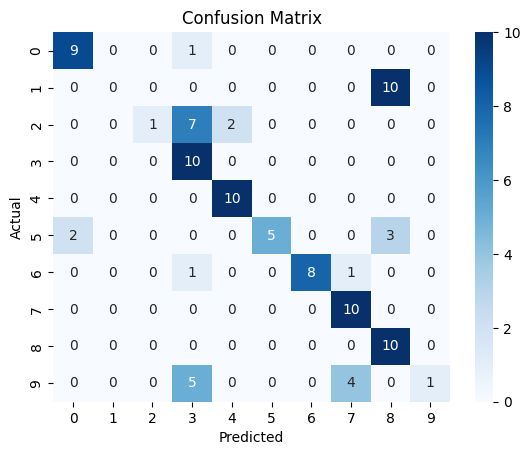

In [75]:
# Convert the entire column
df['Predicted Class Probability Array'] = df['Predicted Class Probability'].apply(convert_string_to_array)

# Convert to proper format
pred_labels_proba = extract_probability_scores(df['Predicted Class Probability Array'])

test_labels, pred_labels, pred_labels_cos_scores  = df['ZSL Unseen Class'], df['ZSL Predicted Class'], df['Predicted Class Probability Array']

evaluate_model_2(test_labels, pred_labels, pred_labels_cos_scores)


In [76]:
df.to_csv('prediction_results_generator_unseen.csv', index=False)

# Ma'am please note this error : ROC-AUC calculation failed: Number of classes in y_true not equal to the number of columns in 'y_score'